<a href="https://colab.research.google.com/github/Ewha-Euron/10th-ML/blob/week_11/%EB%B3%B5%EC%8A%B5%EB%AC%B8%EC%A0%9C_11%EC%A3%BC%EC%B0%A8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 11주차 복습과제: 군집화

다음은 11주차 군집화 세션의 복습과제입니다. 문제 조건에 맞춰 코드를 작성하고, 설명을 추가해 주세요.

---

#Section A: 군집화, K-means

문제 1: 좋은 군집화란?

좋은 군집화의 조건을 설명하시오.

**요구 사항**

군집 내부 응집도(Within-cluster similarity)의 의미를 설명하시오.

군집 간 분리도(Between-cluster dissimilarity)의 의미를 설명하시오.



좋은 군집화는 군집 내부는 단단하게 뭉치고, 군집 끼리는 멀리 떨어져 있는 상태를 만드는 것입니다. 즉 군집 내부 응집도와 군집 간 분리도가 높은 군집화이다. 

군집 내부 응집도 : 같은 군집 안에 포함된 데이터 객체들이 서로 얼마나 닮았는지를 나타내는 지표이다.
군집 간 분리도 : 서로 다른 군집들이 얼마나 명확하게 떨어져 있고 구별되는지를 나타내는 지표이다. 

문제 2: K-Means에서 군집 개수 K는 매우 중요한 파라미터이다.
동일한 데이터에 대해 서로 다른 K값을 적용했을 때 군집화 결과가 어떻게 달라지는지 비교하시오.

데이터 생성 조건
샘플 수 : 400개
군집 수 : 4개
특징 수 : 2개
random_state : 0
수행 조건

다음 K값에 대해 각각 군집화를 수행하시오.

Case 1 : K = 2
Case 2 : K = 4
Case 3 : K = 6
(배운 파라미터를 기반으로 작성하면 됨)

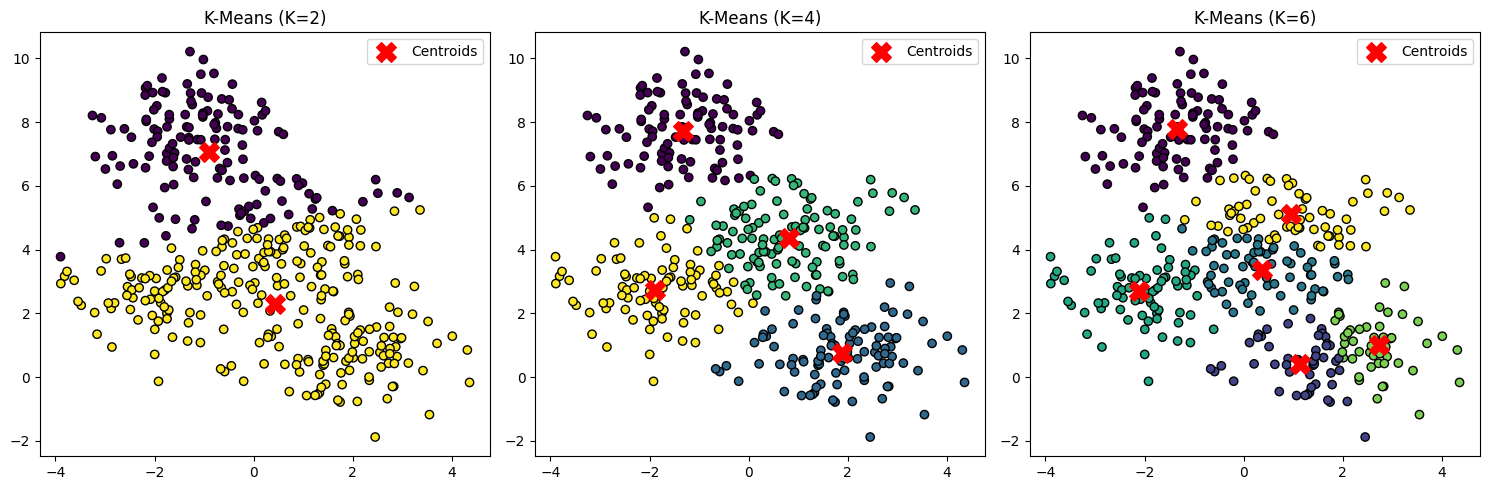

In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=400, centers=4, n_features=2, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k_values = [2, 4, 6]

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    s=200, c='red', marker='X', label='Centroids')
    axes[i].set_title(f'K-Means (K={k})')
    axes[i].legend()

plt.tight_layout()
plt.show()

문제 3 : Elbow Method - 최적 K찾기

K-Means는 사전에 K값을 지정해야 하기 때문에 적절한 군집 개수를 선택하는 과정이 중요하다. Elbow Method를 사용하여 최적의 군집 수를 탐색하시오. 데이터 생성 조건 샘플 수 : 500개 군집 수 : 5개 특징 수 : 2개 random_state : 10

수행 조건 K를 1부터 10까지 변화시키며 K-Means 수행

K값에 따른 SSE 그래프를 그리시오.

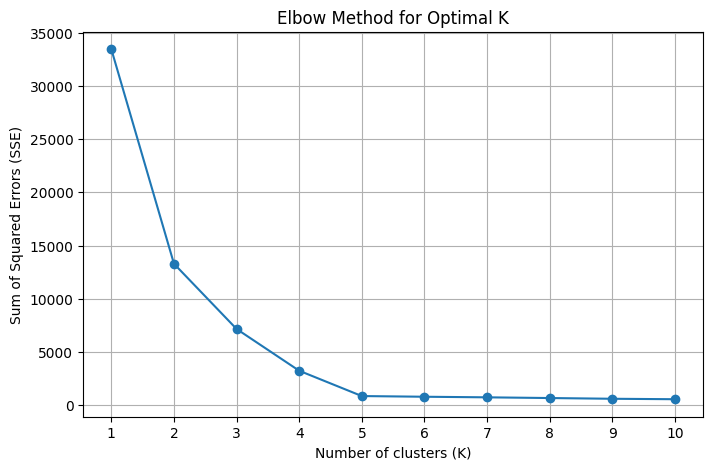

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=500,
    centers=5,
    n_features=2,
    random_state=10
)

#K-means 수행 과정을 작성해주세요
sse = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init='auto')
    kmeans.fit(X)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

문제 4: make_blobs를 이용해 2차원 데이터를 생성하고,
K=3으로 K-Means 군집화를 수행하시오.

centroid를 함께 시각화할 것
random_state=42 사용

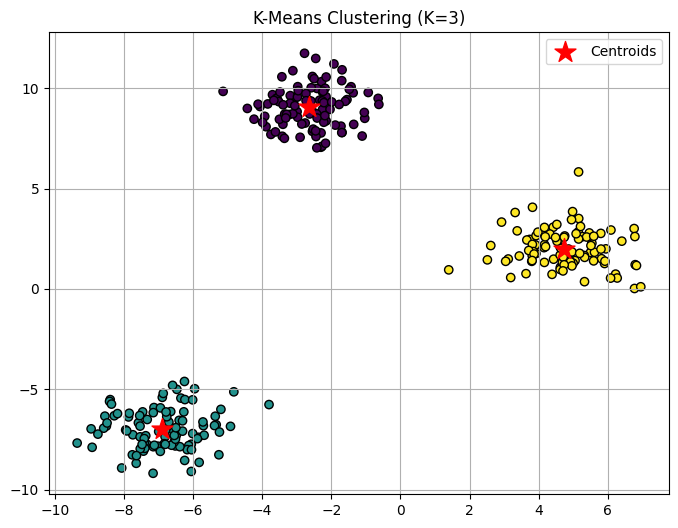

In [5]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성 및 KMeans 수행
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
# centroid 시각화
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='red', marker='*', label='Centroids')
plt.title('K-Means Clustering (K=3)')
plt.legend()
plt.grid(True)
plt.show()

문제 5:
iris 데이터셋에 대해
K=2
K=8로 각각 K-Means 군집화를 수행하고 결과를 시각화하시오.


이를 통해
K가 너무 작을 때의 문제점
K가 너무 클 때의 문제점을 서술하시오.

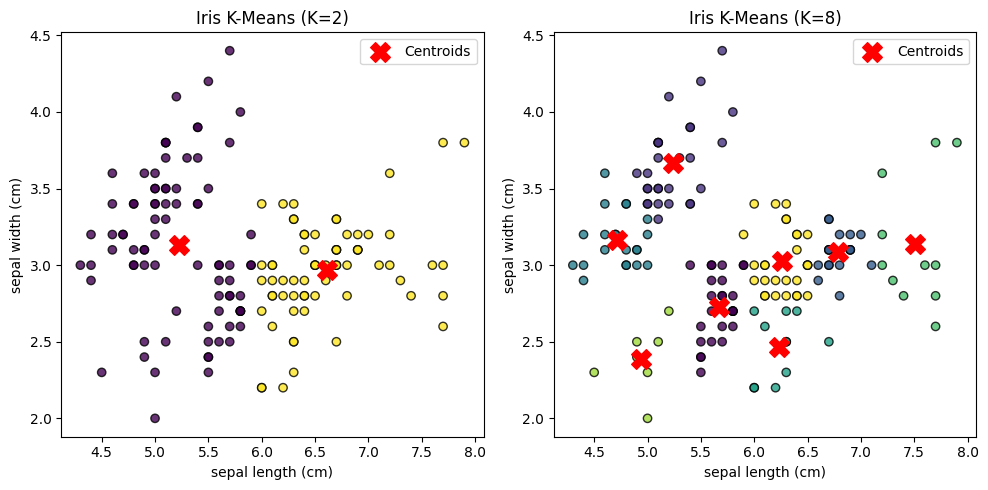

In [6]:
# iris data 불러오기
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]   # 앞 2개 feature만 사용

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10,5))
k_values = [2, 8]

for i, k in enumerate(k_values):
    # K-Means 모델 생성 및 예측
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(X)
    
    # 데이터 산점도 그리기
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.8)
    
    # 각 군집의 중심점(Centroid) 표시
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    s=200, c='red', marker='X', label='Centroids')
    
    axes[i].set_title(f'Iris K-Means (K={k})')
    axes[i].set_xlabel(iris.feature_names[0])
    axes[i].set_ylabel(iris.feature_names[1])
    axes[i].legend()

plt.tight_layout()
plt.show()

K가 너무 작을 때의 문제점 (K = 2)
서로 다른 품종이 하나의 군집으로 무리하게 묶이면서 군집 내부 응집도가 떨어진다. 이로 인해 데이터 고유의 구조와 특성 차이를 포착하지 못하고 유의미한 정보가 손실된다.

K가 너무 클 때의 문제점 (K = 8)
동일한 품종이 불필요하게 여러 개로 쪼개지면서 인접한 군집 간의 경계가 모호해지고 군집 간 분리도가 급격히 저하된다. 이는 노이즈까지 학습한 과적합 상태로, 각 군집의 의미를 해석하기 어려워진다.

문제 6:

실루엣 계수(Silhouette Score)가 무엇인지 간단히 설명하시오.

실루엣 계수가 1, 0, 음수에 가까울 때 각각 어떤 의미를 가지는지 설명하시오.

실루엣 계수 : 군집화가 얼마나 잘 이루어졌는지를 평가하는 지표이다. 각 데이터가 자신이 속한 군집 내부의 데이터와는 얼마나 가깝고, 가장 가까운 이웃 군집의 데이터와는 얼마나 멀리 떨어져 있는지를 계산하여 군집의 적절성을 점수로 나타낸다. 

- 1에 가까울 때: 군집화가 매우 이상적으로 잘 된 상태로 같은 군집 내부의 데이터들은 촘촘하게 모여 있고, 다른 군집과는 확연하게 멀리 떨어져 있음을 뜻한다. 

- 0에 가까울 때: 군집 간의 경계가 모호한 상태로 서로 다른 군집들이 너무 가까이 붙어 있거나 겹쳐 있어서 데이터가 어느 군집에 속하는지 구분이 잘 안 됨을 뜻한다. 

- 음수에 가까울 때: 데이터가 엉뚱한 군집에 잘못 들어간 상태이다. 

문제 7:
iris 데이터셋에 대해 다음 조건으로 K-Means 군집화를 수행하시오.

**요구사항**

군집화를 수행하고 결과를 시각화하시오.

cluster_centers_를 출력하시오.

=== Cluster Centers ===
[[6.81276596 3.07446809]
 [5.77358491 2.69245283]
 [5.006      3.428     ]]


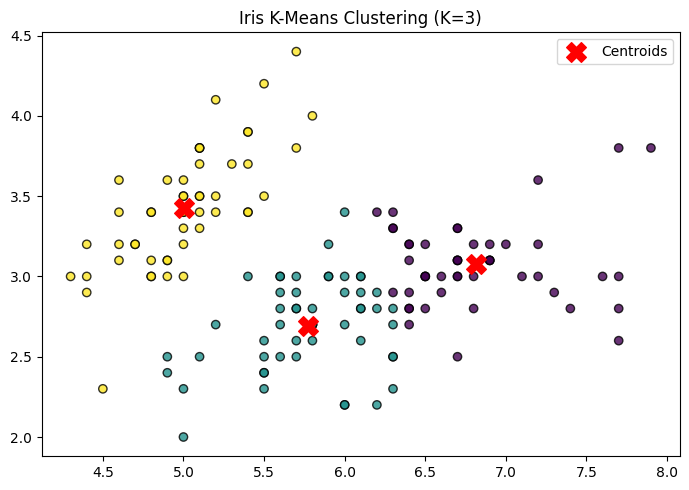

In [14]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. iris 데이터 불러오기 (시각화를 위해 앞의 2개 feature만 사용)
iris = load_iris()
X = iris.data[:, :2]

# 2. 지정된 하이퍼파라미터로 K-Means 모델 생성 및 학습
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
labels = kmeans.fit_predict(X)

# 3. cluster_centers_ (군집 중심점) 출력
print("=== Cluster Centers ===")
print(kmeans.cluster_centers_)
print("=======================")

# 4. 결과 시각화
plt.figure(figsize=(7, 5))

# 데이터 산점도
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.8)

# 군집 중심점(Centroids) 표시
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')

plt.title('Iris K-Means Clustering (K=3)')
plt.legend()
plt.tight_layout()
plt.show()

문제 8: 다음 파라미터들의 역할을 간단히 설명하시오.

n_clusters

init

n_init

max_iter

random_state

- n_clusters: 데이터를 몇 개의 군집으로 나눌지 지정하는 K 값이다. 
- init: 초기 군집 중심점(Centroid)의 배치 방식을 결정한다. 무작위 배치 대신 대개 k-means++를 사용하여 중심점들이 서로 멀리 떨어지도록 효율적으로 초기화한다. 
- n_init: 최적의 결과를 얻기 위해 전체 알고리즘을 처음부터 다시 무작위로 실행할 횟수이다. 
- max_iter: 중심점을 이동하고 군집을 다시 할당하는 내부 연산의 최대 반복 횟수이다. 
- random_state: 무작위 초기화에 사용되는 시드를 고정하여, 코드를 다시 실행해도 언제나 동일한 군집화 결과가 나오도록 제어한다. 

### Section B: 평균 이동, GMM, DBSCAN

#### 문제 1: 평균 이동(Mean Shift) 군집화의 이해

Mean Shift 알고리즘은 KMeans와 유사하게 거리 기반 군집화 방법 중 하나입니다. 이 알고리즘의 동작 방식에 대해 간략히 설명하고, `make_blobs`를 사용하여 가상의 데이터셋을 생성한 후 `MeanShift`를 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

동작 방식 : K-Means와 달리 군집의 개수(K)를 미리 지정할 필요가 없으며, 대신 대역폭을 설정한다. 개별 데이터가 이 반경 내의 평균 중심점을 계산한 뒤 그 방향으로 중심을 계속 이동시키며, 최종적으로 중심점이 더 이상 움직이지 않고 한곳으로 모인 데이터들을 하나의 군집으로 묶어낸다.

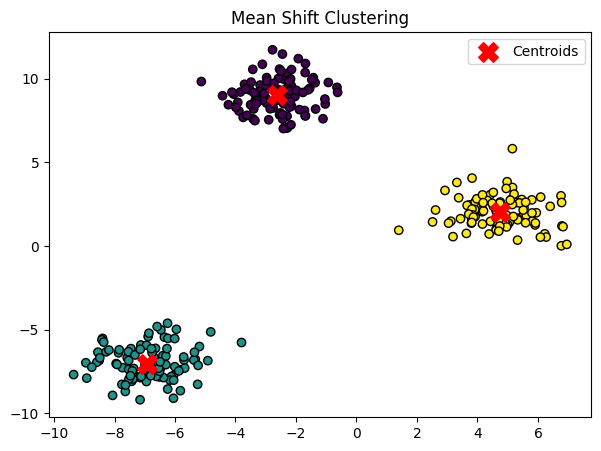

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# Mean Shift 수행
meanshift = MeanShift()
labels = meanshift.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.scatter(meanshift.cluster_centers_[:, 0], meanshift.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title('Mean Shift Clustering')
plt.legend()
plt.show()

#### 문제 2: Mean Shift 군집화 파라미터 이해 및 조정

Mean Shift 알고리즘에서 `bandwidth` 파라미터는 군집화 결과에 큰 영향을 미칩니다. `bandwidth` 값을 다르게 설정했을 때 군집화 결과가 어떻게 달라지는지 확인하기 위해, 다음 조건을 따라 코드를 작성하고 결과를 비교하여 설명하세요.

**데이터 생성 조건:** (문제 1과 동일)
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**MeanShift 설정:**
- Case 1: `bandwidth`를 `estimate_bandwidth`로 추정한 값 사용
- Case 2: `bandwidth`를 추정값의 0.5배로 설정
- Case 3: `bandwidth`를 추정값의 2배로 설정

각 Case별로 군집화 결과를 시각화하고, 군집의 개수 변화와 그 이유를 간략하게 설명하세요.

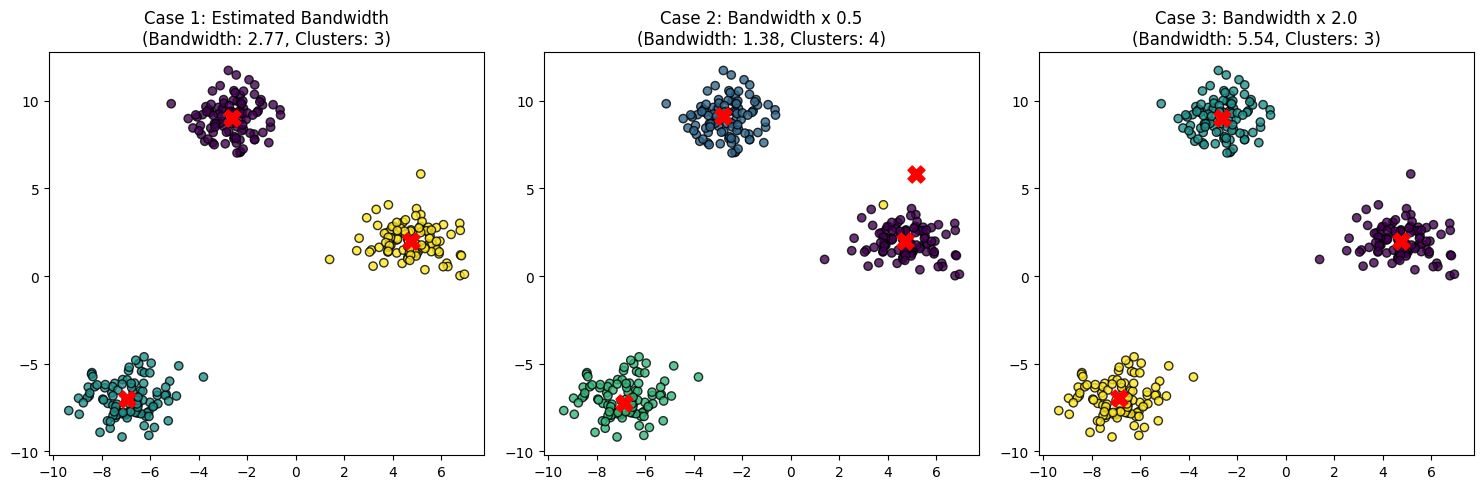

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

base_bandwidth = estimate_bandwidth(X, quantile=0.3)

bandwidths = [base_bandwidth, base_bandwidth * 0.5, base_bandwidth * 2.0]
titles = ['Case 1: Estimated Bandwidth', 'Case 2: Bandwidth x 0.5', 'Case 3: Bandwidth x 2.0']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, bw in enumerate(bandwidths):
    # Mean Shift 모델 학습
    ms = MeanShift(bandwidth=bw)
    labels = ms.fit_predict(X)
    centroids = ms.cluster_centers_
    n_clusters = len(centroids)
    
    # 시각화
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.8)
    axes[i].scatter(centroids[:, 0], centroids[:, 1], s=150, c='red', marker='X', label='Centroids')
    axes[i].set_title(f"{titles[i]}\n(Bandwidth: {bw:.2f}, Clusters: {n_clusters})")

plt.tight_layout()
plt.show()

대역폭을 작게 바꾸면 탐색 반경이 너무 좁아지면서 하나의 큰 데이터 덩어리를 묶지 못하고 내부의 미세한 노이즈나 작은 밀도 차이까지 개별 군집으로 인식해 잘게 쪼개기 때문에 군집의 개수가 불필요하게 많이 증가한다. 반면 대역폭을 크게 바꾸면 탐색 반경이 지나치게 넓어지면서 서로 멀리 떨어져 있는 독립적인 데이터 뭉치들까지 하나의 평균 계산 범위에 포함되어 결국 전체 데이터의 소수의 중심점으로 모두 합쳐지기 때문에 군집의 개수가 급격히 감소한다. 

#### 문제 3: GMM (Gaussian Mixture Model) 군집화 및 KMeans와의 차이점

GMM은 각 군집이 가우시안 분포를 따른다고 가정하는 확률 기반 군집화 알고리즘입니다. GMM의 기본적인 개념과 KMeans와의 주요 차이점을 설명하고, `make_blobs`로 생성된 데이터에 `GaussianMixture`를 적용하여 군집화를 수행하고 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 400개
- 군집 수: 2개
- 특징 수: 2개
- 랜덤 시드: 0
- `cluster_std`를 각각 `[1.0, 2.5]`로 설정하여 타원형 분포를 갖도록 합니다.

**GMM 설정:**
- 군집 수: 2개
- 공분산 타입: `full`
- 랜덤 시드: 0

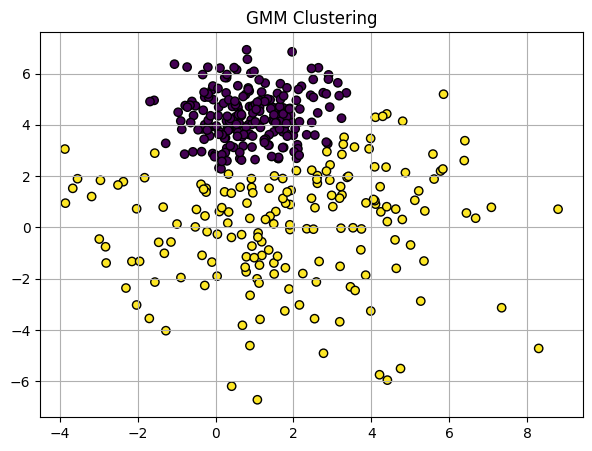

In [13]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=400, centers=2, n_features=2,
                  cluster_std=[1.0, 2.5], random_state=0)

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
labels = gmm.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.title('GMM Clustering')
plt.grid(True)
plt.show()

#### 문제 4: DBSCAN (밀도 기반 군집화) 알고리즘 적용

DBSCAN은 밀도 기반 군집화 방법으로, 군집의 개수를 미리 지정할 필요가 없으며 다양한 형태의 군집을 찾을 수 있습니다. DBSCAN의 주요 파라미터(`eps`, `min_samples`)와 데이터 포인트의 세 가지 유형(`Core`, `Border`, `Noise`)에 대해 설명하고, `make_moons`를 사용하여 초승달 모양 데이터셋을 생성한 후 `DBSCAN`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 200개
- 노이즈 비율: 0.05
- 랜덤 시드: 42

- eps: 개별 데이터 포인트를 기준으로 이웃을 정의하는 탐색 반경
- min_samples: 하나의 군집을 형성하기 위해 eps 반경 내에 존재해야 하는 최소 데이터 포인트 개수(자기 자신 포함)

- Core Point: 자신의 eps 반경 내에 이웃 데이터 포인트가 min_samples 개 이상 존재하는 포인트
- Border Point: 자신의 eps 반경 내의 데이터 개수는 min_samples 미만이지만, 다른 핵심 포인트의 반경 내에 포함되어 있는 포인트
- Noise Point: 핵심 포인트도 아니고 경계 포인트도 아닌 포인트

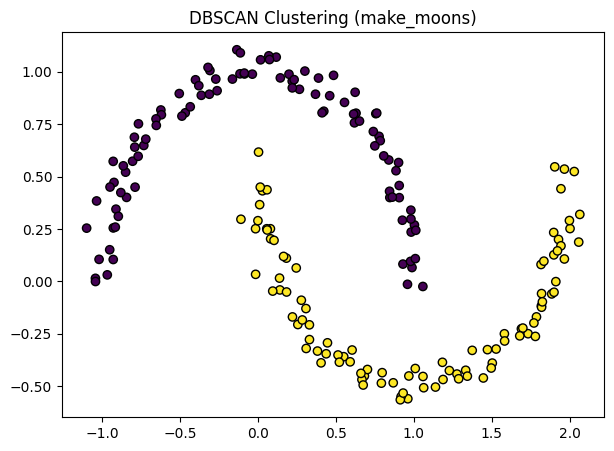

In [15]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.title('DBSCAN Clustering (make_moons)')
plt.show()

### Section C: 병합 군집, 계층적 군집, 고객 세그먼테이션 (RFM)

#### 문제 5: 계층적 군집화 (Agglomerative Clustering)의 이해

계층적 군집화는 데이터를 계층적으로 묶어 트리 형태(덴드로그램)의 구조를 만듭니다. 이 중 병합 군집(Agglomerative Clustering)의 개념에 대해 설명하고, `make_blobs`로 생성된 간단한 데이터셋에 `AgglomerativeClustering`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: `ward`

병합 군집: 모든 데이터를 각각 하나의 독립된 군집으로 두고 시작하여 가장 가까운 군집끼리 차례대로 묶어 나가는 상향식 계층적 군집화 방식 

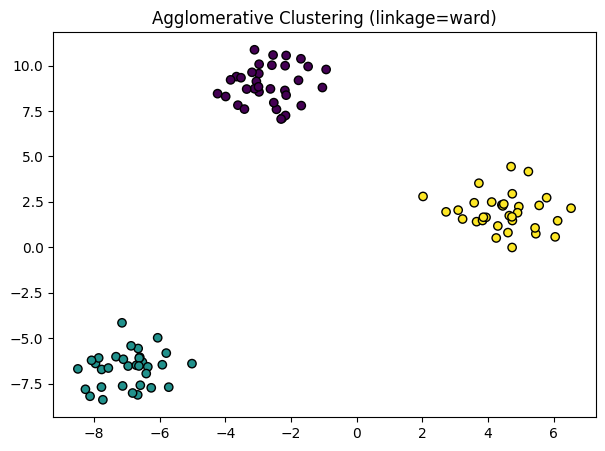

In [16]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

agg_clust = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg_clust.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
plt.title('Agglomerative Clustering (linkage=ward)')
plt.show()

#### 문제 6: 계층적 군집화의 Linkage 옵션

계층적 군집화에서 `linkage` 옵션은 군집 간의 유사성(거리)을 측정하는 방식을 정의하며, 군집화 결과에 중요한 영향을 미칩니다. `linkage` 옵션 중 `ward`, `complete`, `average` 세 가지 방식의 차이점을 간략히 설명하고, 다음 조건을 따라 `AgglomerativeClustering`을 적용하여 결과를 비교 시각화하세요.

**데이터 생성 조건:** (문제 5와 동일)
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: 각각 `ward`, `complete`, `average` 사용

- ward: 군집을 병합했을 때 발생하는 군집 내부의 분산 증가량을 최소화하는 방식이다. 군집 내부 응집도가 높아져 크기가 비교적 균일하고 둥근 형태의 군집을 만든다.

- complete: 두 군집에서 가장 멀리 떨어진 데이터 간의 거리를 기준으로 삼는 방식이다. 군집의 외곽 경계를 기준으로 묶기 때문에 원형의 조밀한 군집을 형성하는 경향이 있다.

- average: 두 군집의 모든 데이터 쌍 간의 평균 거리를 기준으로 삼는 방식이다. 노이즈나 이상치에 덜 민감하며, 데이터 구조를 무난하고 안정적으로 포착한다.

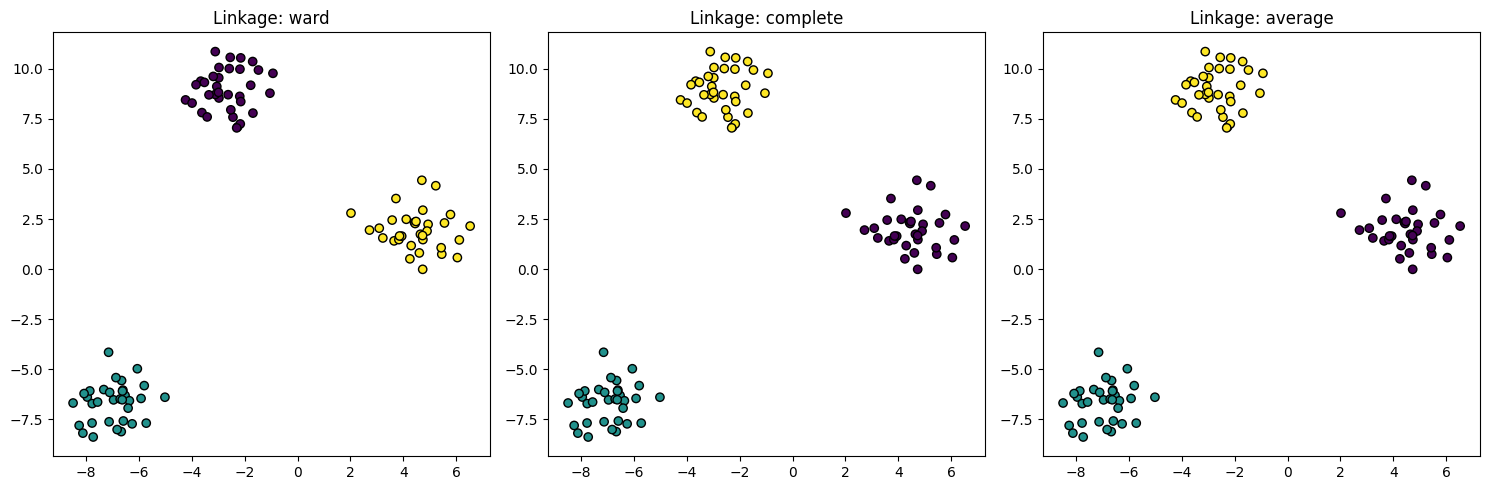

In [17]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

linkages = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, link in enumerate(linkages):
    agg = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agg.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k')
    axes[i].set_title(f"Linkage: {link}")

plt.tight_layout()
plt.show()

#### 문제 7: 고객 세그먼테이션 (RFM 기법)의 개념

고객 세그먼테이션은 마케팅 분야에서 고객을 유사한 특성별로 그룹화하는 데 사용됩니다. 이 중 RFM (Recency, Frequency, Monetary) 기법은 가장 널리 사용되는 방법 중 하나입니다. RFM 각 지표의 의미를 설명하고, 왜 이 세 가지 지표가 고객 가치를 평가하고 세그먼테이션하는 데 효과적인지 간략하게 서술하세요.

RFM 각 지표의 의미
- Recency: 고객이 가장 최근에 서비스를 이용하거나 상품을 구매한 시점이다. 현재와 가까울수록 유익한 고객으로 판단한다.
- Frequency: 고객이 지정된 기간 동안 얼마나 자주 구매했는지 나타내는 빈도다. 방문이나 구매 횟수가 많을수록 브랜드에 대한 충성도가 높다고 본다.
- Monetary: 고객이 일정 기간 동안 지출한 총 금액이다. 기업의 매출에 직접적으로 기여한 실질적인 재정적 가치를 나타낸다.
  
RFM 기법이 효과적인 이유
: RFM 기법은 고객의 과거 행동 데이터를 기반으로 수익성과 미래 행동을 가장 직관적으로 예측할 수 있는 지표들의 조합이기 때문에 효과적이다.

#### 문제 8: RFM 특징 데이터 전처리 및 생성

주어진 가상의 거래 데이터셋을 사용하여 RFM (Recency, Frequency, Monetary) 특징을 생성하세요. RFM은 고객 세그먼테이션을 위한 핵심 지표입니다. 각 RFM 지표를 계산하고, 최종적으로 고객별 RFM 데이터프레임을 생성하세요.

**데이터셋:** 다음 딕셔너리 형태의 데이터를 사용하여 `DataFrame`을 생성합니다.
```python
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
```

**계산 기준일:** `2023-03-01` (이 날짜를 기준으로 Recency를 계산합니다.)

**RFM 지표 계산:**
1. `PurchaseDate` 컬럼을 `datetime` 타입으로 변환합니다.
2. 각 고객(`CustomerID`)별로 다음 RFM 지표를 계산합니다.
   - **Recency:** `계산 기준일`로부터 가장 '최근' 구매일까지의 일수 (작을수록 좋음)
   - **Frequency:** 일정 기간 동안의 총 구매 '횟수'
   - **Monetary:** 일정 기간 동안의 총 구매 '금액' (Price의 합계)
3. 최종적으로 `CustomerID`, `Recency`, `Frequency`, `Monetary` 컬럼을 포함하는 RFM 데이터프레임을 생성하고 첫 5행을 출력합니다.

In [18]:
import pandas as pd
import datetime as dt

data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}

df = pd.DataFrame(data)
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

current_date = pd.to_datetime('2023-03-01')

rfm_df = df.groupby('CustomerID').agg(
    Recency=('PurchaseDate', lambda x: (current_date - x.max()).days), 
    Frequency=('CustomerID', 'count'),
    Monetary=('Price', 'sum')
).reset_index()

print(rfm_df.head())

   CustomerID  Recency  Frequency  Monetary
0           1       28          3       450
1           2       19          2       170
2           3        9          4       630
3           4       24          2       320
4           5       52          2       600
